<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 3: 모델 추가 학습**

## **미션 설명**

- 이번 단계에서는 다음과 같이 3개의 미션을 수행합니다.

### 미션 8: 전처리 파이프라인 만들기

- 새로운 학습용/검증용 데이터에 대해 매번 전처리 작업을 수행해야 합니다.
- 반복되는 전처리 작업은 비효율적인 업무 중 하나입니다.
- 이러한 문제를 해결하기 위해 다음과 같은 처리를 일괄 수행하는 파이프라인 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등

### 미션 9: 기본 모델로 예측 및 평가

- 이전 과정에서 만든 모델이 기본 모델(Base Model)입니다.
- 새로 전달 받은 평가용 데이터로 기존에 만든 모델의 성능을 평가해봅니다.

### 미션 10: 추가 학습

- 문제 상황에 맞게 가장 적절한 방법으로 모델 추가 학습을 진행합니다.
- 추가 학습 후 이전에 평가했던 새로운 평가 데이터로 다시 평가해 성능 향상을 확인합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [1]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Mounted at /content/drive


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [3]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [70]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [71]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [72]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)


In [73]:
# 함수 만들기
def build_model_input(data):

  # 1. 결측치 처리
    # 수치형 변수 결측치 → 중앙값
    num_cols = data.select_dtypes(include=['number']).columns
    data[num_cols] = data[num_cols].fillna(data[num_cols].median())

    # 범주형 변수 결측치 → 최빈값
    cat_cols = data.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        data[col] = data[col].fillna(data[col].mode()[0])

  # 2. 값 변경
    data['Satisfaction'] = data['Satisfaction'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

  # 3. 변수 제거
    data.drop(columns=['Unnamed: 0', 'ID'], inplace=True)

  # 4. 라벨 인코딩
    cat_cols = data.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        encoder = LabelEncoder()
        data[col] = encoder.fit_transform(data[col])

  # 5. 가변수화
    categories = [0, 1, 2, 3, 4, 5]
    dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                 'Inflight entertainment', 'On-board service', 'Leg room service',
                 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
    for col in dumm_cols:
          data[col] = pd.Categorical(data[col], categories=categories)
    data = pd.get_dummies(data, columns=dumm_cols)

  # 6. x, y 분리
    target = 'Satisfaction'
    x = data.drop(target, axis=1)
    y = data.loc[:, target]

  # 7. 스케일링
    x = scaler.transform(x)

    # 반환
    return x, y

- 점검: 다음 구문이 잘 수행되어 x_val, y_val이 분리되어야 합니다.


In [24]:
# x_val, y_val 나누기
x_val, y_val = build_model_input(new_test)

# 확인
print(x_val.shape)
print(y_val.shape)

(350, 92)
(350,)


## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [74]:
# x_val, y_val 나누기
x_val, y_val = build_model_input(new_test)

### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

In [27]:
y_pred = base_model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       191
           1       0.81      0.98      0.89       159

    accuracy                           0.89       350
   macro avg       0.90      0.90      0.89       350
weighted avg       0.90      0.89      0.89       350



## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- new_train 데이터프레임을 x_train, y_train으로 분리합니다.

In [75]:
x_train, y_train = build_model_input(new_train)

### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

In [30]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x_train.shape[1]

# Sequential 모델 선언
Retraining_model = Sequential([
    Input(shape=(nfeatures,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

- 학습 방법을 설정하고 학습을 수행합니다.

In [31]:
# 학습 설정
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=10)
Retraining_model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy')
# 모델 학습
Retraining_hist = Retraining_model.fit(x_train, y_train, epochs=200, validation_split=0.2, callbacks=[es], verbose=0).history

In [35]:
print(y_train.value_counts())

Satisfaction
0    463
1    387
Name: count, dtype: int64


- 학습 곡선을 확인합니다.

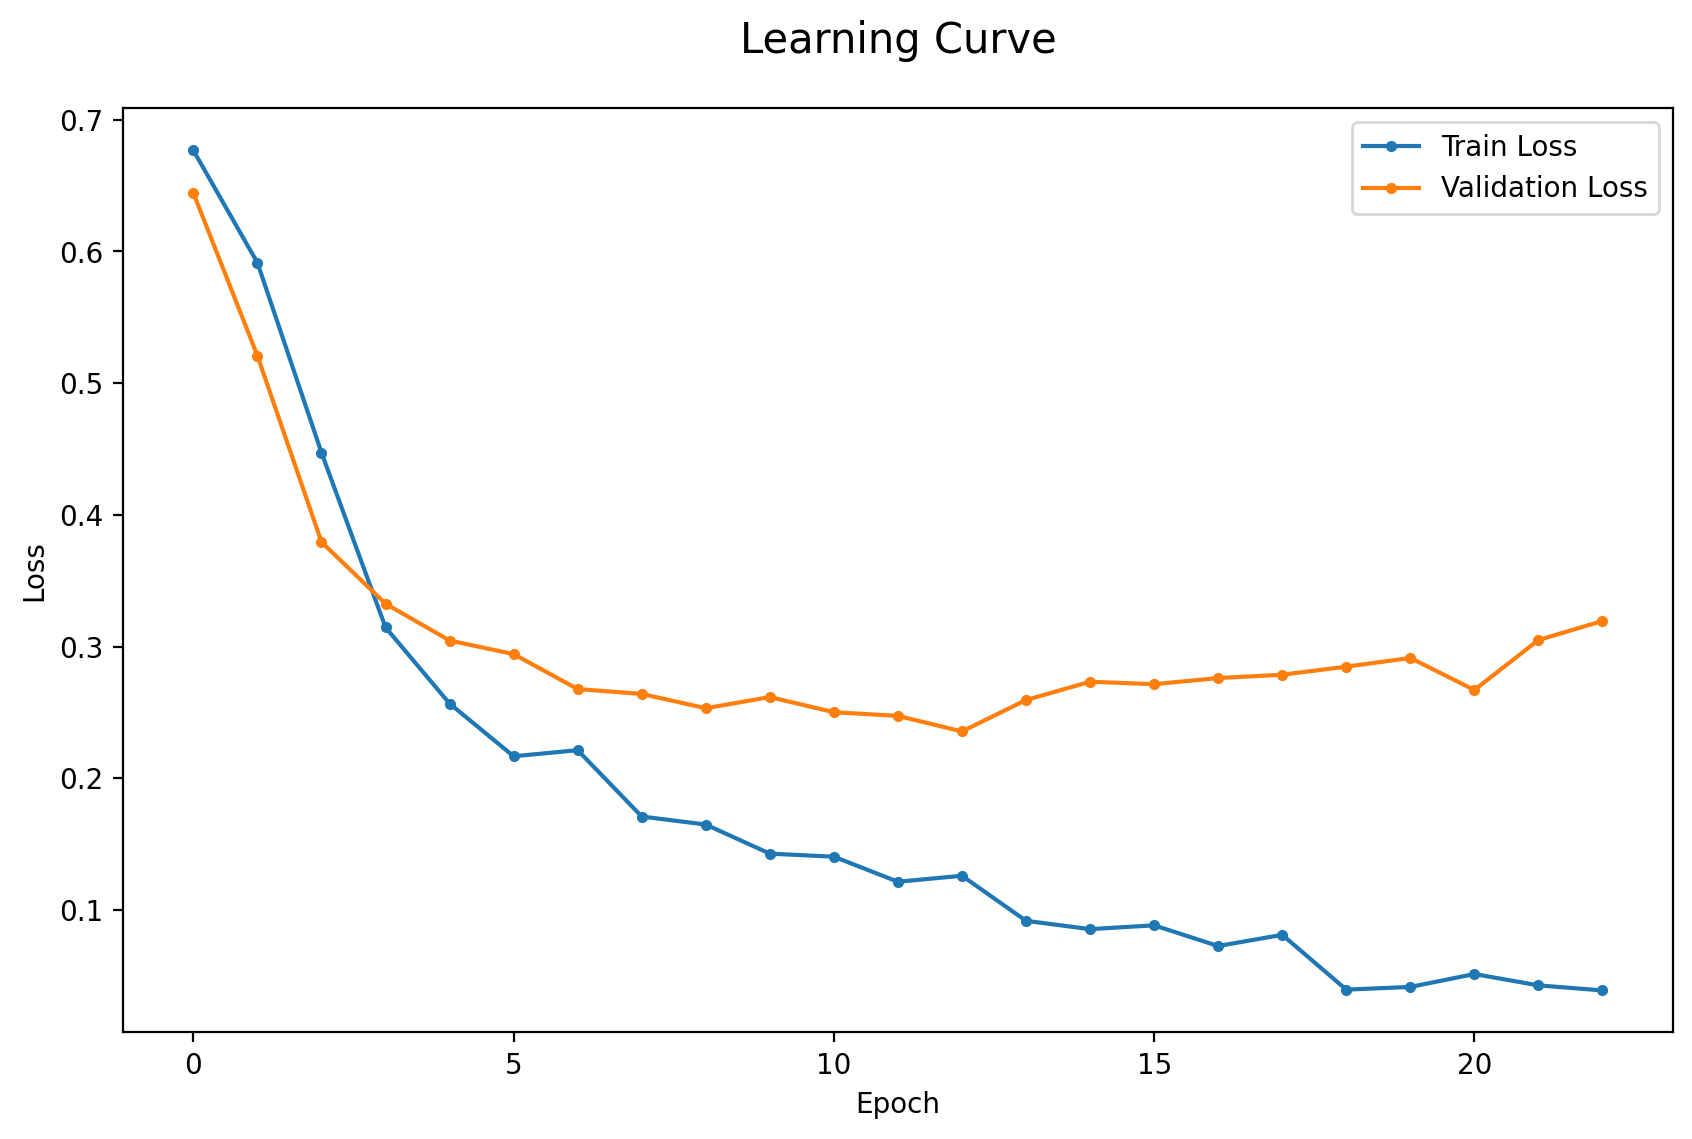

In [40]:
dl_history_plot(Retraining_hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [76]:
y_pred = Retraining_model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       191
           1       0.90      0.90      0.90       159

    accuracy                           0.91       350
   macro avg       0.91      0.91      0.91       350
weighted avg       0.91      0.91      0.91       350



In [41]:
# 가중치를 랜덤으로 초기화하고 new_train 데이터로 처음부터 학습
# new_train 데이터에만 최적화됨

### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

In [77]:
continue_model = load_model(path + 'base_model.keras')

- 학습 방법을 설정하고 학습을 수행합니다.

In [78]:
# 학습 설정
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=10)
continue_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy')
# 모델 학습
continue_hist = continue_model.fit(x_train, y_train, epochs=200, validation_split=0.2, callbacks=[es], verbose=0).history

- 학습 곡선을 확인합니다.

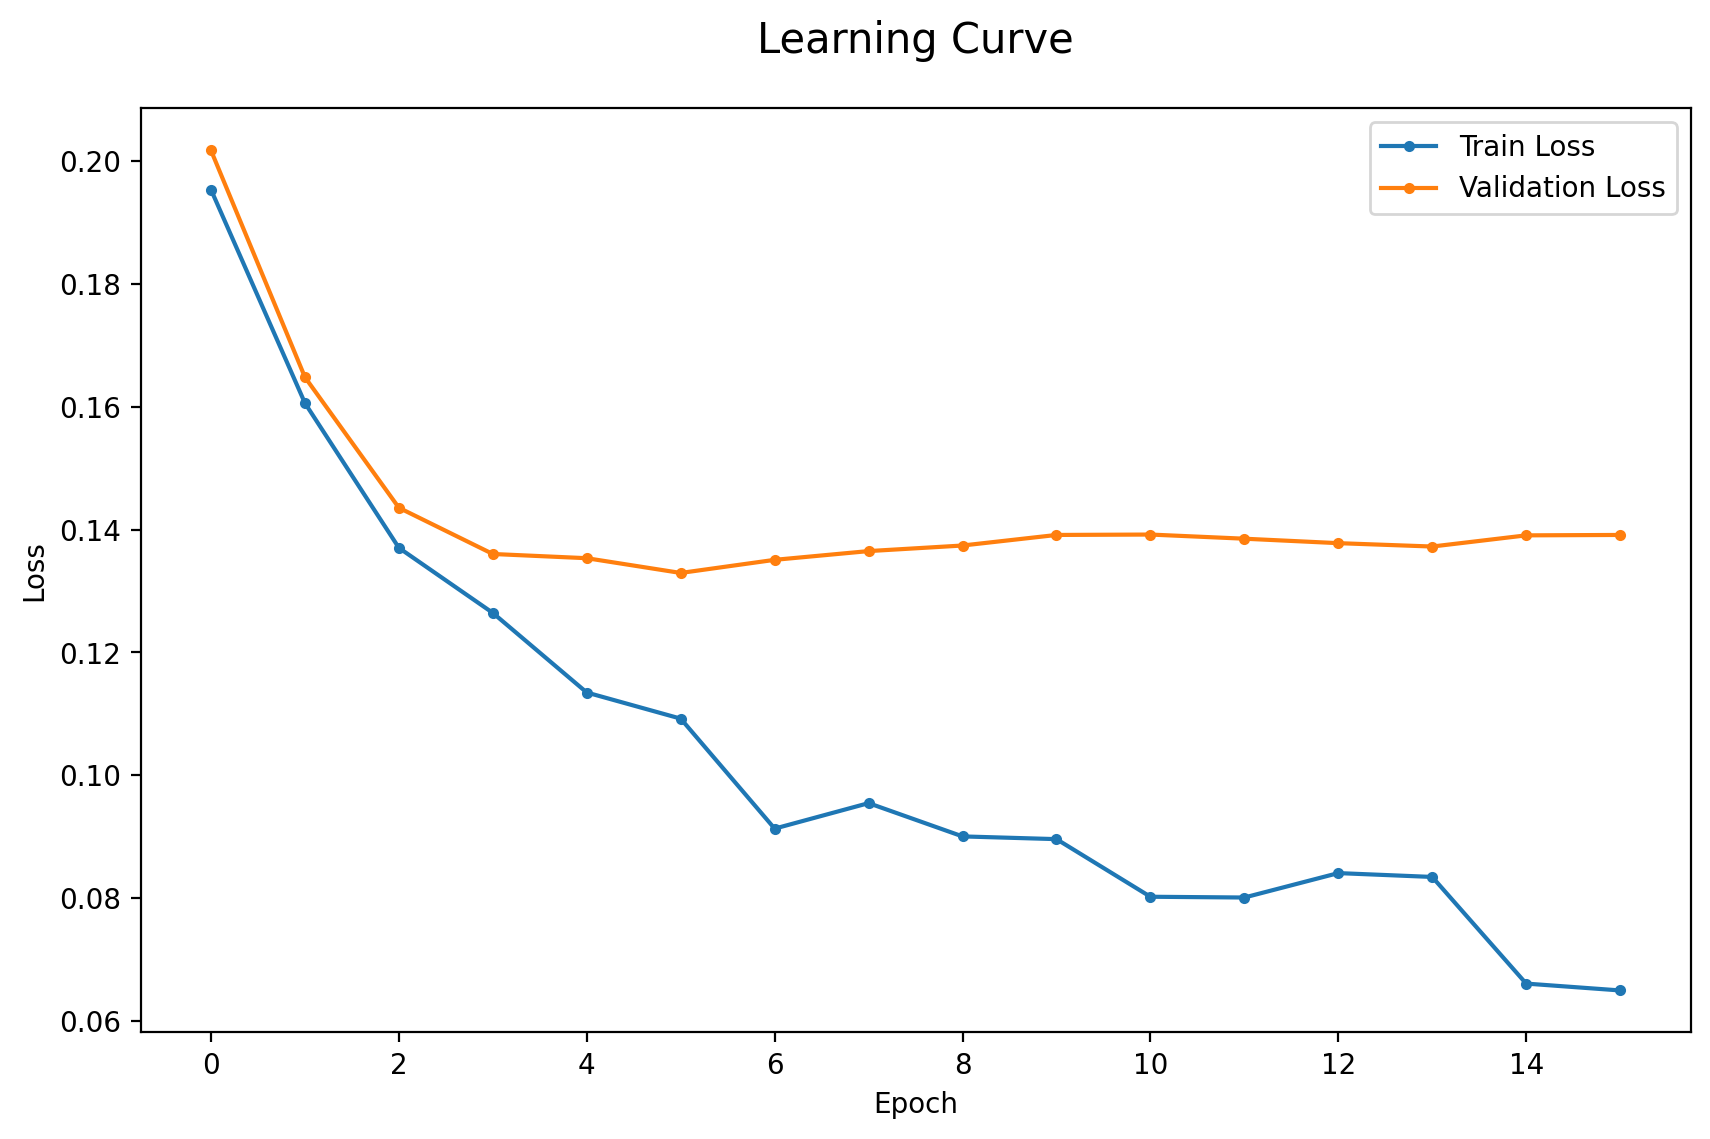

In [79]:
dl_history_plot(continue_hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [80]:
y_pred = continue_model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       191
           1       0.94      0.91      0.93       159

    accuracy                           0.93       350
   macro avg       0.94      0.93      0.93       350
weighted avg       0.93      0.93      0.93       350



In [ ]:
# base_model의 기존 가중치를 그대로 유지하고 new_train으로 추가 학습
# 기존 survey.csv로 학습한 지식 + new_train 데이터 모두 반영됨
# 새로운 데이터 양에 비해 과도하게 많은 파라미터로 학습이 진행돼 과적합 발생

### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [105]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

# 마지막 레이어 제거
base_model.pop()

<Dense name=dense_4, built=True>

In [106]:
# 앞쪽 레이어 학습 비활성화
for layer in base_model.layers[:-2]:
    layer.trainable = False

# 새 출력층 추가
fine_model = Sequential([
    base_model,
    Dense(1, activation='sigmoid')
])
fine_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32)             │        67,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,073 (262.00 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 64,960 (253.75 KB)

- 학습 방법을 설정하고 학습을 수행합니다.

In [107]:
# 학습 설정
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=10)
fine_model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy')
# 모델 학습
fine_hist = fine_model.fit(x_train, y_train, epochs=200, validation_split=0.2, callbacks=[es], verbose=0).history

- 학습 곡선을 확인합니다.

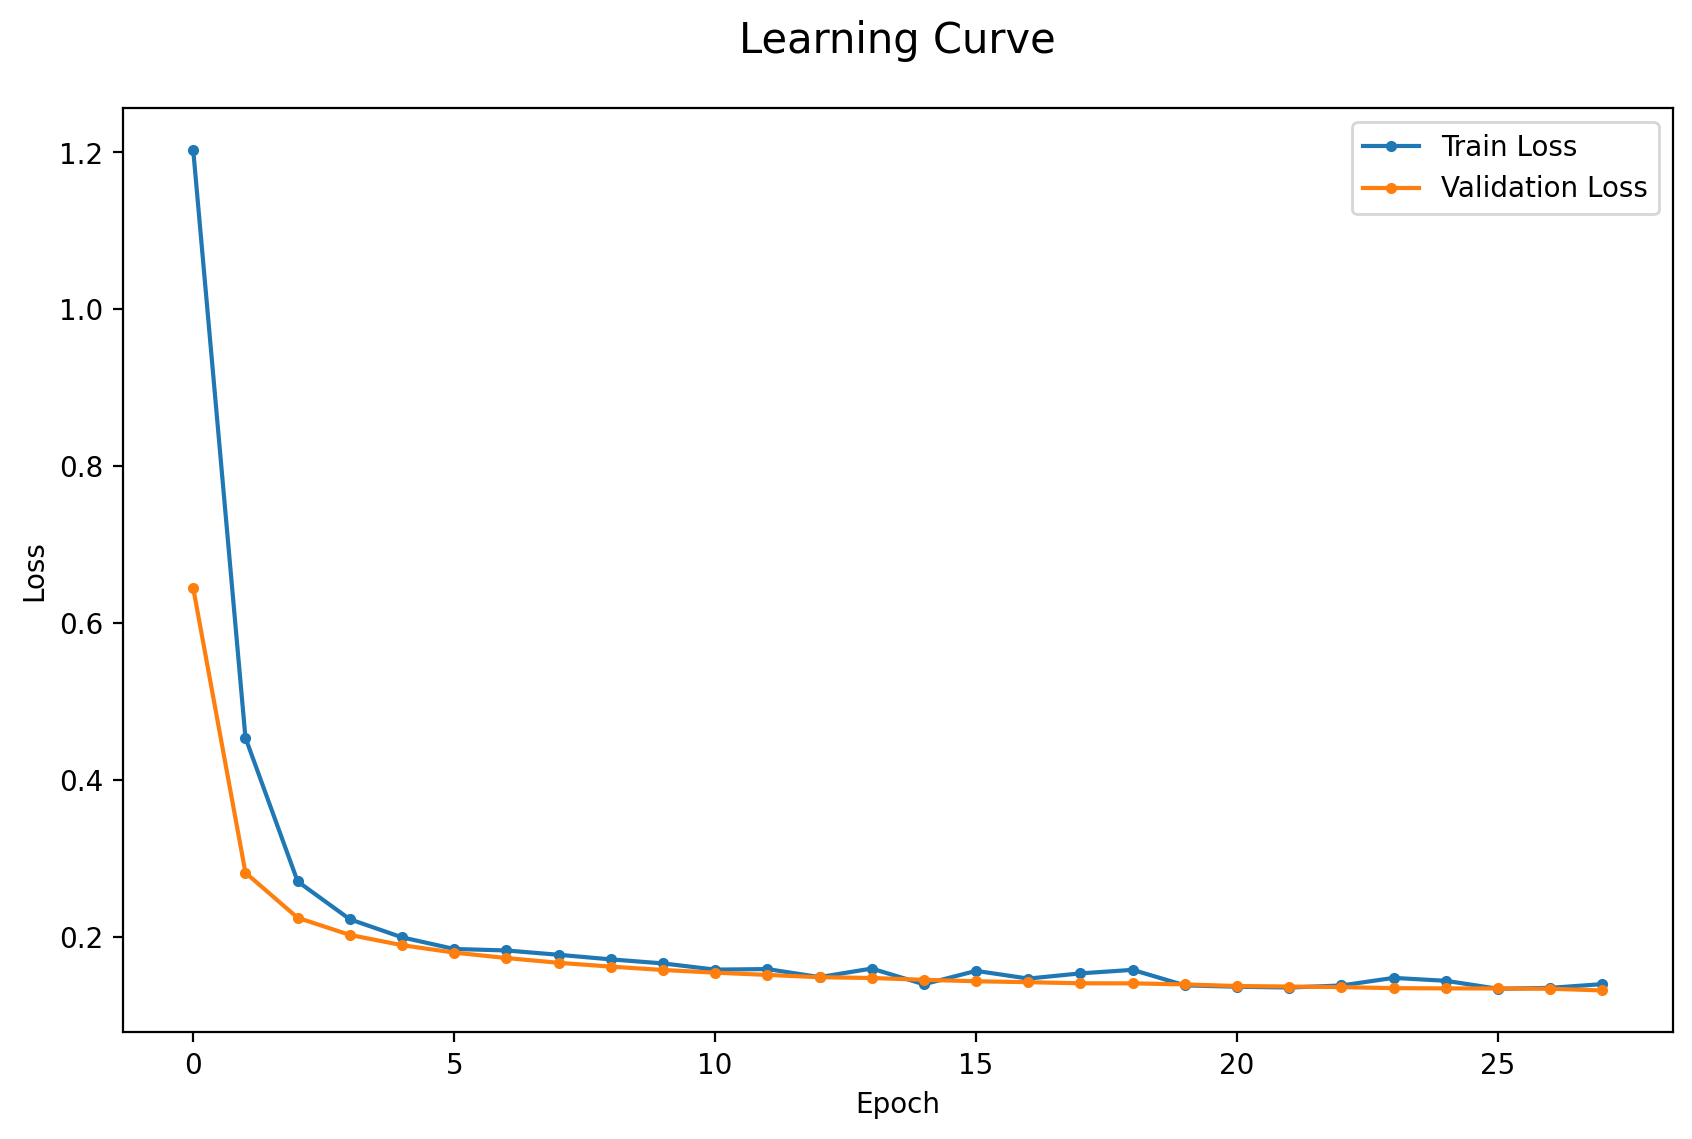

In [108]:
dl_history_plot(fine_hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [109]:
y_pred = fine_model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       191
           1       0.90      0.95      0.93       159

    accuracy                           0.93       350
   macro avg       0.93      0.93      0.93       350
weighted avg       0.93      0.93      0.93       350



In [ ]:
# 성능은 방법 2와 비슷하지만 학습 곡선이 훨씬 안정적
# 추가 데이터 수가 적은 만큼 파라미터 수를 줄여 과적합을 방지

In [ ]:
# 기존 모델에 의한 만족도 예측이 실제와 달랐던 이유
## 기존 데이터는 target값의 클래스 불균형이 심했지만 새로운 데이터는 균형잡힌 데이터로 새로운 고객의 패턴을 기존 모델이 반영하지 못함

# 기존 모델이 학습한 데이터의 상황(특이점, 문제점)
## 클래스 불균형 문제로 불만족(0) 고객 예측 성능이 상대적으로 낮았음

# 더 나은 고객 서비스를 위해 수행해야 될 고객 관리 전략
## Inflight wifi service, Online boarding 품질 향상 우선 투자
## Eco/Eco Plus 클래스 고객 만족도 개선 필요 (Business 대비 만족도 낮음)
## Personal travel 고객 대상 별도 서비스 전략 수립